# Customer Churn Predictive Modeling

## Predicting Retail Banking Customer Attrition with Machine Learning

### Project Objective

Customer churn can directly affect recurring revenue, customer lifetime value, and acquisition costs. The objective of this project is to determine whether customer demographics, financial characteristics, and account activity can be used to identify customers at greater risk of leaving a retail bank.

I compare four supervised machine learning classification models:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- Decision Tree

Rather than selecting a model based on accuracy alone, I evaluate performance using precision, recall, F1-score, ROC-AUC, cross-validation, and generalization to unseen data.

### Business Question

Which classification model provides the strongest balance of predictive performance and generalization for identifying customers at risk of churn?

## 1. Environment & Libraries

This analysis uses Python's data analysis, visualization, and machine learning libraries to prepare the customer data, train classification models, and evaluate predictive performance.

The primary libraries include pandas and NumPy for data manipulation, Matplotlib and Seaborn for visualization, and scikit-learn for preprocessing, model development, and evaluation.

In [1]:
# Module provides access to system-specific parameters and functions
import sys

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Suppress warnings
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully')

All libraries imported successfully


## 2. Data Loading & Initial Exploration

The dataset contains 10,000 retail banking customer records. The target variable, `Exited`, identifies whether a customer remained with the bank (`0`) or churned (`1`).

Before modeling, I examine the dataset structure, descriptive statistics, missing values, and target distribution to understand the quality and characteristics of the available data.

In [2]:
# Upload the Churn_Modelling.csv file to Google Colab
if 'google.colab' in sys.modules:
    import os
    from google.colab import files

    if not os.path.exists('Churn_Modelling.csv'):
        print("Please upload the dataset file.")
        uploaded = files.upload()
    else:
        print("The dataset file was already uploaded.")

Please upload the dataset file.


Saving Churn_Modelling.csv to Churn_Modelling.csv


In [3]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

print('Dataset loaded successfully')
print('Dataset shape:', df.shape)

print('\nFirst few rows:')
print(df.head())

Dataset loaded successfully
Dataset shape: (10000, 13)

First few rows:
   RowNumber  CustomerId   Surname  CreditScore  Gender  Age  Tenure  \
0          1    15634602  Hargrave          619  Female   42       2   
1          2    15647311      Hill          608  Female   41       1   
2          3    15619304      Onio          502  Female   42       8   
3          4    15701354      Boni          699  Female   39       1   
4          5    15737888  Mitchell          850  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       

In [4]:
# Display dataset information
print('Dataset Information:')
print(df.info())

print('\nDataset Statistics:')
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 1015.8+ KB
None

Dataset Statistics:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000

In [5]:
# Check for missing values
print('Missing Values:')

missing = df.isnull().sum()

print(
    missing[missing > 0]
    if missing.sum() > 0
    else 'No missing values found'
)

Missing Values:
No missing values found


Target Variable Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate:
20.37%


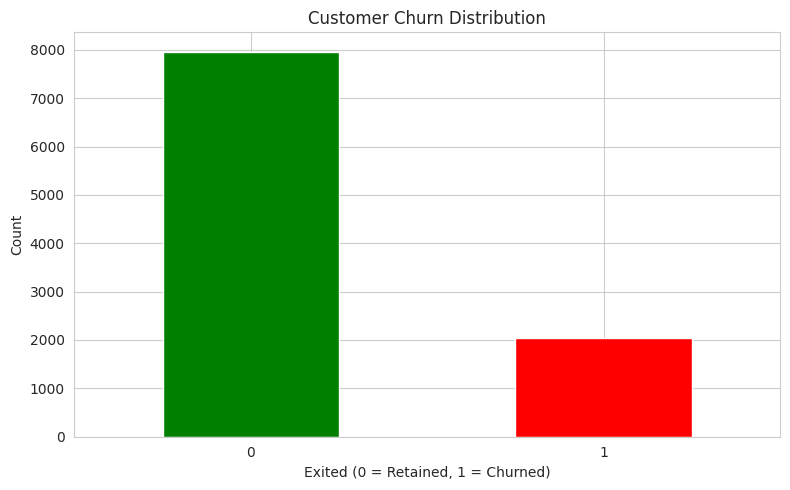

In [6]:
# Analyze target variable distribution
print('Target Variable Distribution:')
print(df['Exited'].value_counts())

print('\nChurn Rate:')
churn_rate = df['Exited'].mean() * 100
print(f'{churn_rate:.2f}%')

# Visualize target distribution
plt.figure(figsize=(8, 5))
df['Exited'].value_counts().plot(
    kind='bar',
    color=['green', 'red']
)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Retained, 1 = Churned)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Initial Observation: Class Imbalance

Of the 10,000 customers in the dataset:

- 7,963 customers were retained
- 2,037 customers churned
- Overall churn rate: 20.37%

The target variable is therefore imbalanced, with approximately four retained customers for every customer who churned.

This affects how model performance should be evaluated. Accuracy alone may overstate performance if a model performs well on the majority retained class but fails to identify customers who actually churn.

For this reason, precision, recall, F1-score, confusion matrices, and ROC-AUC will be evaluated alongside accuracy.

In [7]:
# Establish a majority-class baseline
majority_baseline = (df['Exited'] == 0).mean()

print(f"Majority-Class Baseline Accuracy: {majority_baseline:.2%}")

Majority-Class Baseline Accuracy: 79.63%


### Baseline Performance

Because 79.63% of customers belong to the retained class, a naive model that predicted every customer would remain could achieve approximately 79.63% accuracy without identifying a single churner.

This baseline provides important context for interpreting model accuracy. A useful churn model should not only exceed this baseline but also demonstrate an ability to identify customers in the minority churn class.

## 3. Data Preprocessing

Before exploring feature relationships, I prepared the dataset by removing identifier fields that were not useful for prediction and encoding categorical data into a numerical format.

`RowNumber`, `CustomerId`, and `Surname` were removed because they function as identifiers rather than customer characteristics intended for churn prediction.

The `Gender` variable was then encoded numerically so it could be included in the modeling workflow.

In [8]:
# Drop irrelevant columns
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']

df_processed = df.drop(columns=columns_to_drop)

print('Dropped columns:', columns_to_drop)
print('Remaining columns:', df_processed.columns.tolist())

# Encode categorical variables
label_encoder = LabelEncoder()

df_processed['Gender'] = label_encoder.fit_transform(
    df_processed['Gender']
)

print('\nEncoded Gender column (0 = Female, 1 = Male)')
print('\nProcessed dataset shape:', df_processed.shape)

Dropped columns: ['RowNumber', 'CustomerId', 'Surname']
Remaining columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Encoded Gender column (0 = Female, 1 = Male)

Processed dataset shape: (10000, 10)


## 4. Exploratory Data Analysis

### Feature Relationships

Before training the models, I examined correlations among the numerical features and the `Exited` target variable.

The correlation matrix provides an initial view of linear relationships in the dataset. It can help identify potentially useful predictors, but correlation alone does not capture nonlinear relationships or interactions between customer characteristics.

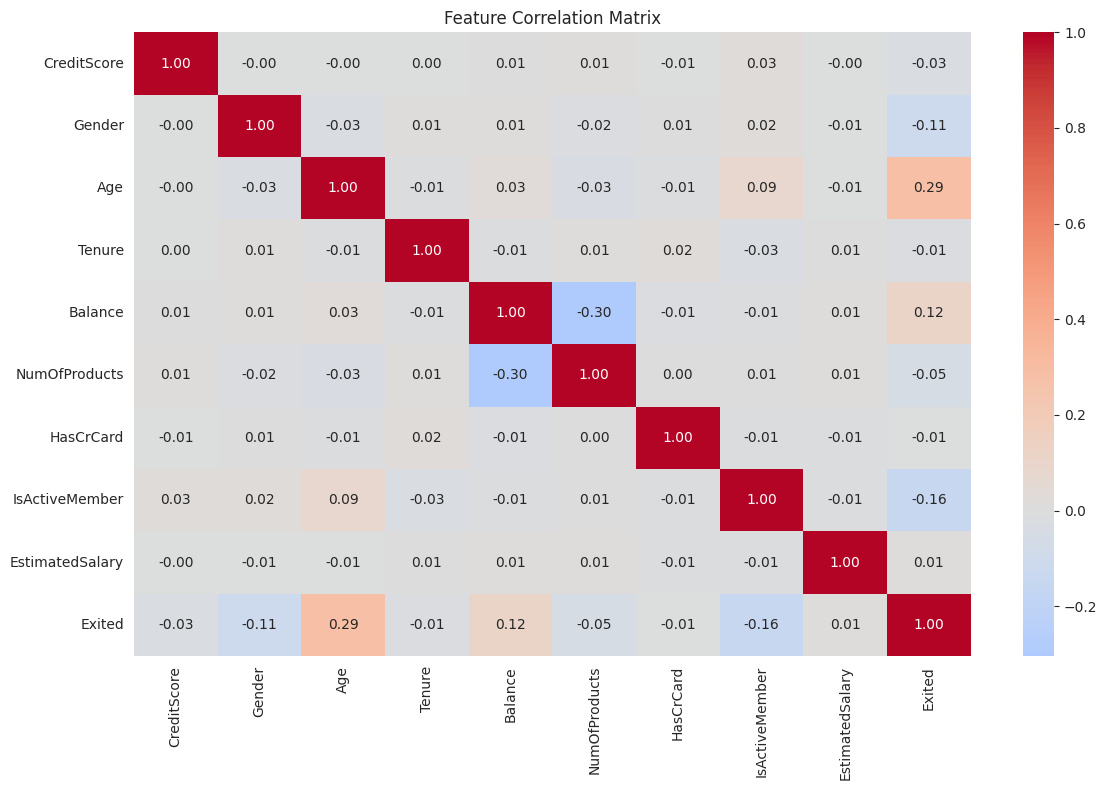

Correlation with target variable (Exited):
Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Gender            -0.106512
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [9]:
# Correlation analysis
plt.figure(figsize=(12, 8))

correlation_matrix = df_processed.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with target variable (Exited):')
print(
    correlation_matrix['Exited']
    .sort_values(ascending=False)
)

### EDA Findings

The correlation analysis identified several initial relationships with customer churn:

- `Age` showed the strongest positive correlation with churn at approximately 0.285.
- `Balance` showed a smaller positive correlation of approximately 0.119.
- `IsActiveMember` had the strongest negative correlation with churn at approximately -0.156.
- `Gender` showed a negative correlation of approximately -0.107.
- `Tenure`, `CreditScore`, and `NumOfProducts` showed relatively weak linear relationships with churn.

These findings provide an initial view of the relationships within the data, but all nine predictive features were retained for modeling.

A weak linear correlation does not necessarily mean that a feature has little predictive value. More complex models, particularly tree-based algorithms, can identify nonlinear patterns and interactions between variables that may not be visible through correlation alone.

## 5. Train-Test Split & Feature Scaling

In [10]:
# Separate features and target
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
print('\nFeatures:', X.columns.tolist())

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('\nTraining set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

print('\nTraining set churn rate:', (y_train.mean() * 100), '%')
print('Testing set churn rate:', (y_test.mean() * 100), '%')

Feature matrix shape: (10000, 9)
Target vector shape: (10000,)

Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Training set size: 8000
Testing set size: 2000

Training set churn rate: 20.375 %
Testing set churn rate: 20.349999999999998 %


In [11]:
# Feature scaling
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed')
print('\nScaled training data shape:', X_train_scaled.shape)
print('Scaled testing data shape:', X_test_scaled.shape)

Feature scaling completed

Scaled training data shape: (8000, 9)
Scaled testing data shape: (2000, 9)


## 5. Train-Test Split & Feature Scaling

The processed dataset was separated into predictive features (`X`) and the churn target (`y`).

I used an 80/20 stratified train-test split:

- Training set: 8,000 customers
- Testing set: 2,000 customers

Stratified sampling preserved the churn distribution across both datasets, with approximately 20.4% churn in both the training and testing sets.

### Feature Scaling

The predictive variables operate on different numerical scales. To place the features on a comparable scale, I standardized them using `StandardScaler`.

The scaler was fitted only on the training data and then applied to the testing data. This prevents information from the test set from influencing preprocessing during model development.

## 6. Model Development

Four supervised classification algorithms were trained using the same training and testing datasets to provide a consistent comparison:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest
4. Decision Tree

Each model was evaluated using training and testing accuracy, precision, recall, F1-score, ROC-AUC, and five-fold cross-validation.

Using multiple evaluation metrics is especially important because the churn class represents only about 20% of the dataset.

## 6.1 Logistic Regression

Logistic Regression serves as an interpretable baseline classification model.

The model estimates the probability of customer churn based on the relationship between the predictive features and the binary `Exited` outcome. Its performance provides a useful benchmark for determining whether more complex nonlinear models improve churn prediction.

In [12]:
# Train Logistic Regression model
print('Training Logistic Regression model...')

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_precision = precision_score(y_test, lr_test_pred)
lr_recall = recall_score(y_test, lr_test_pred)
lr_f1 = f1_score(y_test, lr_test_pred)
lr_auc = roc_auc_score(y_test, lr_test_proba)

# Cross-validation
lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5
)

print('\nLogistic Regression Results:')
print(f'Training Accuracy: {lr_train_acc:.4f}')
print(f'Testing Accuracy: {lr_test_acc:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall: {lr_recall:.4f}')
print(f'F1-Score: {lr_f1:.4f}')
print(f'AUC-ROC: {lr_auc:.4f}')
print(f'Cross-Validation Mean: {lr_cv_scores.mean():.4f}')
print(f'Cross-Validation Std: {lr_cv_scores.std():.4f}')

print('\nClassification Report:')
print(
    classification_report(
        y_test,
        lr_test_pred,
        target_names=['Retained', 'Churned']
    )
)

Training Logistic Regression model...

Logistic Regression Results:
Training Accuracy: 0.8073
Testing Accuracy: 0.8050
Precision: 0.5825
Recall: 0.1474
F1-Score: 0.2353
AUC-ROC: 0.7711
Cross-Validation Mean: 0.8074
Cross-Validation Std: 0.0044

Classification Report:
              precision    recall  f1-score   support

    Retained       0.82      0.97      0.89      1593
     Churned       0.58      0.15      0.24       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.76      2000



### Logistic Regression Interpretation

Logistic Regression achieved 80.50% testing accuracy, only slightly above the 79.63% majority-class baseline.

The model's main weakness was its ability to identify customers who actually churned. Recall for the churn class was only 14.74%, meaning the model identified fewer than 15% of actual churners. This resulted in an F1-score of 0.2353.

The classification report also shows the effect of class imbalance. Recall was 97% for retained customers but only 15% for churned customers.

Training accuracy of 80.73%, testing accuracy of 80.50%, and cross-validation accuracy of 80.74% were very close, indicating stable performance with little evidence of overfitting.

While Logistic Regression provides a useful baseline, its low churn recall limits its effectiveness for a business objective focused on identifying customers before they leave.

### 6.2 Support Vector Machine (SVM)

Support Vector Machine was evaluated as a nonlinear classification approach using the radial basis function (RBF) kernel.

Unlike Logistic Regression, SVM can capture more complex decision boundaries between retained and churned customers. Probability estimates were enabled so ROC-AUC could be evaluated consistently across all four models.

In [13]:
# Train SVM model
print('Training Support Vector Machine model...')

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Make predictions
svm_train_pred = svm_model.predict(X_train_scaled)
svm_test_pred = svm_model.predict(X_test_scaled)
svm_test_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)
svm_precision = precision_score(y_test, svm_test_pred)
svm_recall = recall_score(y_test, svm_test_pred)
svm_f1 = f1_score(y_test, svm_test_pred)
svm_auc = roc_auc_score(y_test, svm_test_proba)

# Cross-validation
svm_cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5
)

print('\nSupport Vector Machine Results:')
print(f'Training Accuracy: {svm_train_acc:.4f}')
print(f'Testing Accuracy: {svm_test_acc:.4f}')
print(f'Precision: {svm_precision:.4f}')
print(f'Recall: {svm_recall:.4f}')
print(f'F1-Score: {svm_f1:.4f}')
print(f'AUC-ROC: {svm_auc:.4f}')
print(f'Cross-Validation Mean: {svm_cv_scores.mean():.4f}')
print(f'Cross-Validation Std: {svm_cv_scores.std():.4f}')

print('\nClassification Report:')
print(
    classification_report(
        y_test,
        svm_test_pred,
        target_names=['Retained', 'Churned']
    )
)

Training Support Vector Machine model...

Support Vector Machine Results:
Training Accuracy: 0.8596
Testing Accuracy: 0.8580
Precision: 0.8361
Recall: 0.3759
F1-Score: 0.5186
AUC-ROC: 0.7976
Cross-Validation Mean: 0.8506
Cross-Validation Std: 0.0038

Classification Report:
              precision    recall  f1-score   support

    Retained       0.86      0.98      0.92      1593
     Churned       0.84      0.38      0.52       407

    accuracy                           0.86      2000
   macro avg       0.85      0.68      0.72      2000
weighted avg       0.86      0.86      0.84      2000



### SVM Interpretation

Support Vector Machine substantially improved churn prediction compared with Logistic Regression.

Testing accuracy increased to 85.80%, while precision reached 83.61%. This means that when SVM classified a customer as likely to churn, the prediction was correct at a relatively high rate.

More importantly, recall increased from 14.74% with Logistic Regression to 37.59% with SVM. The F1-score also increased from 0.2353 to 0.5186, demonstrating a much better balance between precision and recall for the churn class.

Training accuracy of 85.96% and testing accuracy of 85.80% were nearly identical, indicating little evidence of overfitting. Five-fold cross-validation produced a mean accuracy of 85.06%, further supporting stable model performance.

SVM represents a clear improvement over the Logistic Regression baseline, but more than 60% of actual churners were still not identified.

### 6.3 Random Forest

Random Forest was evaluated as an ensemble tree-based model capable of capturing nonlinear relationships and interactions among customer characteristics.

The model combines predictions from multiple decision trees, which can improve predictive performance and reduce the overfitting associated with relying on a single tree.

In addition to classification performance, Random Forest provides feature importance scores that can help identify which customer characteristics contributed most to the model's predictions.

In [14]:
# Train Random Forest model
print('Training Random Forest model...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)
rf_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)
rf_auc = roc_auc_score(y_test, rf_test_proba)

# Cross-validation
rf_cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5
)

print('\nRandom Forest Results:')
print(f'Training Accuracy: {rf_train_acc:.4f}')
print(f'Testing Accuracy: {rf_test_acc:.4f}')
print(f'Precision: {rf_precision:.4f}')
print(f'Recall: {rf_recall:.4f}')
print(f'F1-Score: {rf_f1:.4f}')
print(f'AUC-ROC: {rf_auc:.4f}')
print(f'Cross-Validation Mean: {rf_cv_scores.mean():.4f}')
print(f'Cross-Validation Std: {rf_cv_scores.std():.4f}')

print('\nClassification Report:')
print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=['Retained', 'Churned']
    )
)

# Feature importance
print('\nFeature Importance:')

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

Training Random Forest model...

Random Forest Results:
Training Accuracy: 0.8938
Testing Accuracy: 0.8595
Precision: 0.8000
Recall: 0.4128
F1-Score: 0.5446
AUC-ROC: 0.8472
Cross-Validation Mean: 0.8571
Cross-Validation Std: 0.0078

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.80      0.41      0.54       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000


Feature Importance:
           Feature  Importance
2              Age    0.338686
5    NumOfProducts    0.228344
4          Balance    0.102923
8  EstimatedSalary    0.093820
0      CreditScore    0.090591
7   IsActiveMember    0.072170
3           Tenure    0.044588
1           Gender    0.017862
6        HasCrCard    0.011017


### Random Forest Interpretation

Random Forest produced the strongest overall results so far.

The model achieved 85.95% testing accuracy and an ROC-AUC of 0.8472. Its recall of 41.28% was higher than both Logistic Regression and SVM, meaning it identified a larger share of customers who actually churned.

Random Forest also achieved an F1-score of 0.5446, providing the best balance between precision and recall among the models evaluated so far.

Training accuracy was 89.38% compared with testing accuracy of 85.95%, producing a gap of approximately 3.43 percentage points. Five-fold cross-validation accuracy of 85.71% was also very close to test performance, supporting the model's ability to generalize to unseen data.

### Feature Importance

Random Forest also provides insight into which variables contributed most to its predictions.

The five most influential features were:

1. `Age` — 33.87%
2. `NumOfProducts` — 22.83%
3. `Balance` — 10.29%
4. `EstimatedSalary` — 9.38%
5. `CreditScore` — 9.06%

Age and number of products accounted for approximately 57% of total feature importance.

An interesting finding is that `NumOfProducts` showed only a weak linear correlation with churn during exploratory analysis but became the second-most-important feature in the Random Forest model. This suggests that its predictive value may involve nonlinear relationships or interactions with other customer characteristics.

Feature importance reflects how much the model relied on each variable for prediction. It should not be interpreted as evidence that these variables directly cause customer churn.

### 6.4 Decision Tree

Decision Tree was evaluated as a standalone tree-based classifier.

Like Random Forest, a Decision Tree can capture nonlinear relationships without assuming a linear relationship between the predictors and churn. Comparing the two also helps demonstrate whether combining many trees in an ensemble provides better generalization than relying on a single tree.

In [15]:
# Train Decision Tree model
print('Training Decision Tree model...')

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

# Make predictions
dt_train_pred = dt_model.predict(X_train_scaled)
dt_test_pred = dt_model.predict(X_test_scaled)
dt_test_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)
dt_precision = precision_score(y_test, dt_test_pred)
dt_recall = recall_score(y_test, dt_test_pred)
dt_f1 = f1_score(y_test, dt_test_pred)
dt_auc = roc_auc_score(y_test, dt_test_proba)

# Cross-validation
dt_cv_scores = cross_val_score(
    dt_model,
    X_train_scaled,
    y_train,
    cv=5
)

print('\nDecision Tree Results:')
print(f'Training Accuracy: {dt_train_acc:.4f}')
print(f'Testing Accuracy: {dt_test_acc:.4f}')
print(f'Precision: {dt_precision:.4f}')
print(f'Recall: {dt_recall:.4f}')
print(f'F1-Score: {dt_f1:.4f}')
print(f'AUC-ROC: {dt_auc:.4f}')
print(f'Cross-Validation Mean: {dt_cv_scores.mean():.4f}')
print(f'Cross-Validation Std: {dt_cv_scores.std():.4f}')

print('\nClassification Report:')
print(
    classification_report(
        y_test,
        dt_test_pred,
        target_names=['Retained', 'Churned']
    )
)

# Feature importance
print('\nFeature Importance:')

dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(dt_feature_importance)

Training Decision Tree model...

Decision Tree Results:
Training Accuracy: 0.8941
Testing Accuracy: 0.8330
Precision: 0.6420
Recall: 0.4054
F1-Score: 0.4970
AUC-ROC: 0.7788
Cross-Validation Mean: 0.8285
Cross-Validation Std: 0.0097

Classification Report:
              precision    recall  f1-score   support

    Retained       0.86      0.94      0.90      1593
     Churned       0.64      0.41      0.50       407

    accuracy                           0.83      2000
   macro avg       0.75      0.67      0.70      2000
weighted avg       0.82      0.83      0.82      2000


Feature Importance:
           Feature  Importance
2              Age    0.336605
5    NumOfProducts    0.227485
7   IsActiveMember    0.102555
0      CreditScore    0.093788
4          Balance    0.090275
8  EstimatedSalary    0.086356
3           Tenure    0.034869
1           Gender    0.019798
6        HasCrCard    0.008269


### Decision Tree Interpretation

Decision Tree achieved 83.30% testing accuracy with a recall of 40.54% and an F1-score of 0.4970.

The model identified a similar proportion of churners as Random Forest, but its precision was considerably lower at 64.20% compared with 80.00% for Random Forest. This means the Decision Tree generated more false-positive churn predictions.

The model also showed the largest difference between training and testing accuracy. Training accuracy reached 89.41%, while testing accuracy fell to 83.30%, producing a gap of approximately 6.11 percentage points.

Five-fold cross-validation accuracy of 82.85% was close to the 83.30% test result, but the larger training-to-testing gap suggests that the standalone Decision Tree learned patterns in the training data that did not generalize as effectively to unseen customers.

Compared with the Decision Tree, Random Forest retained the benefits of nonlinear tree-based modeling while producing stronger accuracy, precision, F1-score, ROC-AUC, and generalization.

## 7. Model Performance Comparison

After training all four classification models, I compared their performance across multiple evaluation metrics.

Because the dataset is imbalanced, model selection was not based on accuracy alone. Precision, recall, F1-score, ROC-AUC, cross-validation performance, and generalization were considered together.

In [16]:
# Create comprehensive comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest',
        'Decision Tree'
    ],
    'Training Accuracy': [
        lr_train_acc,
        svm_train_acc,
        rf_train_acc,
        dt_train_acc
    ],
    'Testing Accuracy': [
        lr_test_acc,
        svm_test_acc,
        rf_test_acc,
        dt_test_acc
    ],
    'Precision': [
        lr_precision,
        svm_precision,
        rf_precision,
        dt_precision
    ],
    'Recall': [
        lr_recall,
        svm_recall,
        rf_recall,
        dt_recall
    ],
    'F1-Score': [
        lr_f1,
        svm_f1,
        rf_f1,
        dt_f1
    ],
    'AUC-ROC': [
        lr_auc,
        svm_auc,
        rf_auc,
        dt_auc
    ],
    'CV Mean': [
        lr_cv_scores.mean(),
        svm_cv_scores.mean(),
        rf_cv_scores.mean(),
        dt_cv_scores.mean()
    ],
    'CV Std': [
        lr_cv_scores.std(),
        svm_cv_scores.std(),
        rf_cv_scores.std(),
        dt_cv_scores.std()
    ]
})

print('\nComprehensive Model Comparison:')
print(comparison_df.to_string(index=False))

# Identify best model for each metric
print('\nBest Model by Metric:')

print(
    f"Testing Accuracy: "
    f"{comparison_df.loc[comparison_df['Testing Accuracy'].idxmax(), 'Model']}"
)

print(
    f"Precision: "
    f"{comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']}"
)

print(
    f"Recall: "
    f"{comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']}"
)

print(
    f"F1-Score: "
    f"{comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']}"
)

print(
    f"AUC-ROC: "
    f"{comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']}"
)


Comprehensive Model Comparison:
              Model  Training Accuracy  Testing Accuracy  Precision   Recall  F1-Score  AUC-ROC  CV Mean   CV Std
Logistic Regression           0.807250            0.8050   0.582524 0.147420  0.235294 0.771121 0.807375 0.004444
                SVM           0.859625            0.8580   0.836066 0.375921  0.518644 0.797560 0.850625 0.003791
      Random Forest           0.893750            0.8595   0.800000 0.412776  0.544571 0.847174 0.857125 0.007772
      Decision Tree           0.894125            0.8330   0.642023 0.405405  0.496988 0.778786 0.828500 0.009744

Best Model by Metric:
Testing Accuracy: Random Forest
Precision: SVM
Recall: Random Forest
F1-Score: Random Forest
AUC-ROC: Random Forest


## Visual Model Performance

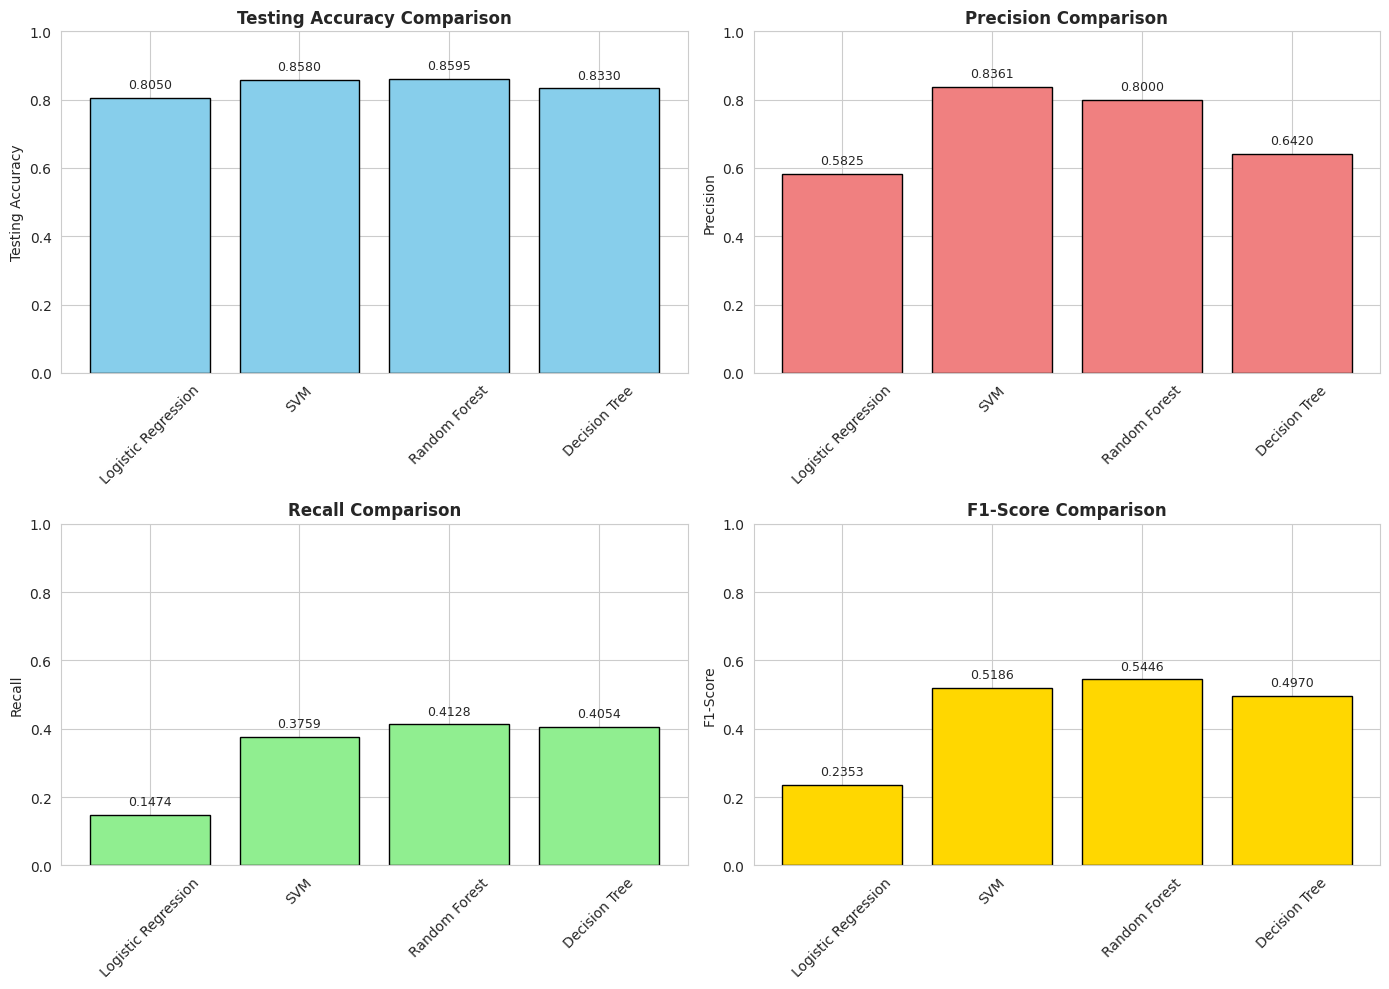

In [17]:
# Visualize model performance metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    'Testing Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

colors = [
    'skyblue',
    'lightcoral',
    'lightgreen',
    'gold'
]

for ax, metric, color in zip(axes.flat, metrics, colors):
    ax.bar(
        comparison_df['Model'],
        comparison_df[metric],
        color=color,
        edgecolor='black'
    )

    ax.set_title(
        f'{metric} Comparison',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel(metric)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)

    # Add value labels
    for i, v in enumerate(comparison_df[metric]):
        ax.text(
            i,
            v + 0.02,
            f'{v:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

### Performance Comparison Findings

The model comparison shows that no single metric should determine the final model selection.

Random Forest achieved the highest testing accuracy at 85.95%, narrowly exceeding SVM at 85.80%. More importantly for the churn prediction objective, Random Forest achieved the highest recall at 41.28% and the highest F1-score at 0.5446.

SVM achieved the highest precision at 83.61%, indicating that its positive churn predictions were more precise. Its recall of 37.59%, though, was lower than both Random Forest and Decision Tree.

Decision Tree achieved a recall of 40.54%, close to Random Forest, but its precision fell to 64.20%. This indicates a greater number of false-positive churn predictions.

Logistic Regression achieved 80.50% accuracy but only 14.74% recall. This reinforces why accuracy alone is not sufficient for evaluating performance on an imbalanced churn dataset.

Overall, Random Forest provides the strongest balance between identifying actual churners and maintaining reliable predictive performance.

## 8. Confusion Matrix Analysis

To better understand the types of classification errors produced by each model, I examined their confusion matrices.

For a customer churn problem, two errors are particularly important:

- False Negative: A customer actually churns, but the model predicts that the customer will remain.
- False Positive: A customer remains, but the model predicts that the customer will churn.

False negatives are especially important from a retention perspective because the business may miss an opportunity to intervene with a customer who is actually at risk.

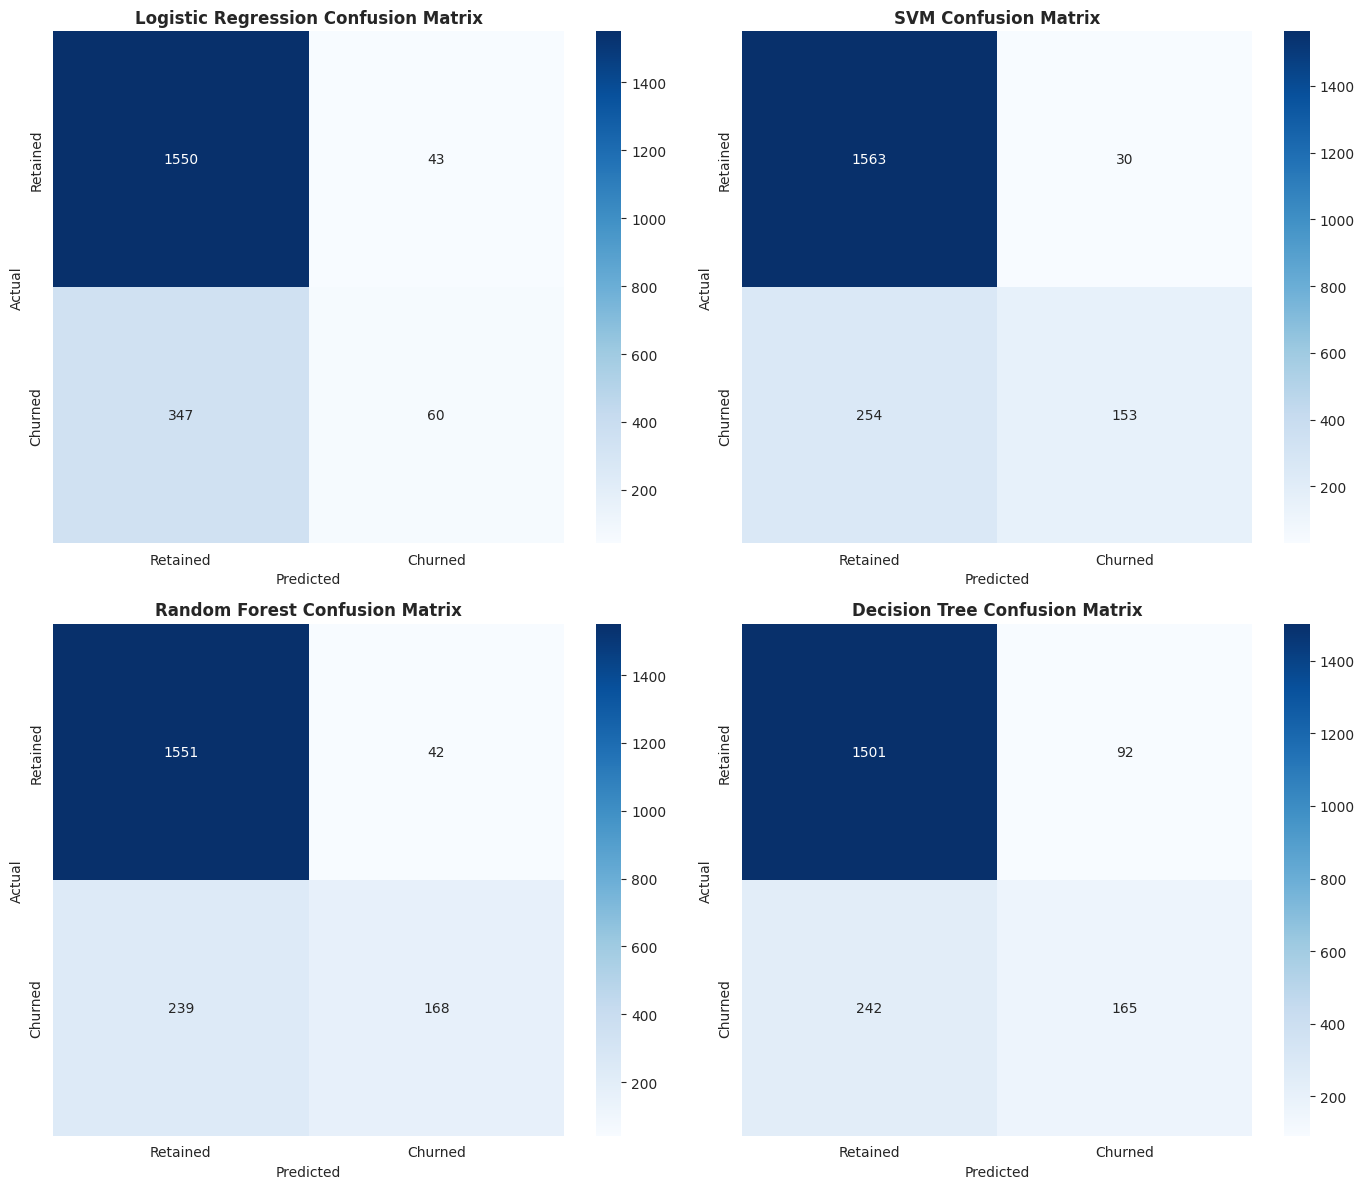

In [18]:
# Create confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models_data = [
    ('Logistic Regression', lr_test_pred),
    ('SVM', svm_test_pred),
    ('Random Forest', rf_test_pred),
    ('Decision Tree', dt_test_pred)
]

for ax, (model_name, predictions) in zip(axes.flat, models_data):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Retained', 'Churned'],
        yticklabels=['Retained', 'Churned']
    )

    ax.set_title(
        f'{model_name} Confusion Matrix',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### Confusion Matrix Findings

The confusion matrices provide a clearer view of how each model handled the 407 customers in the test set who actually churned.

- Logistic Regression correctly identified only 60 churners and missed 347.
- SVM correctly identified 153 churners and produced only 30 false churn alerts.
- Random Forest correctly identified 168 churners, the highest number among the four models, while missing 239.
- Decision Tree correctly identified 165 churners but produced 92 false churn alerts, the highest number among the models.

These results highlight the tradeoff between precision and recall.

SVM was more conservative when predicting churn, resulting in fewer false-positive predictions and the highest precision.

Random Forest identified the largest number of actual churners while maintaining substantially higher precision than Decision Tree. For a retention-focused business problem, this provides a stronger balance between identifying at-risk customers and avoiding unnecessary interventions.

## 9. ROC-AUC Analysis

Receiver Operating Characteristic (ROC) curves were used to evaluate how effectively each model distinguished between retained and churned customers across different classification thresholds.

The Area Under the Curve (AUC) provides an overall measure of this discrimination ability. A higher AUC indicates stronger separation between the two customer outcomes.

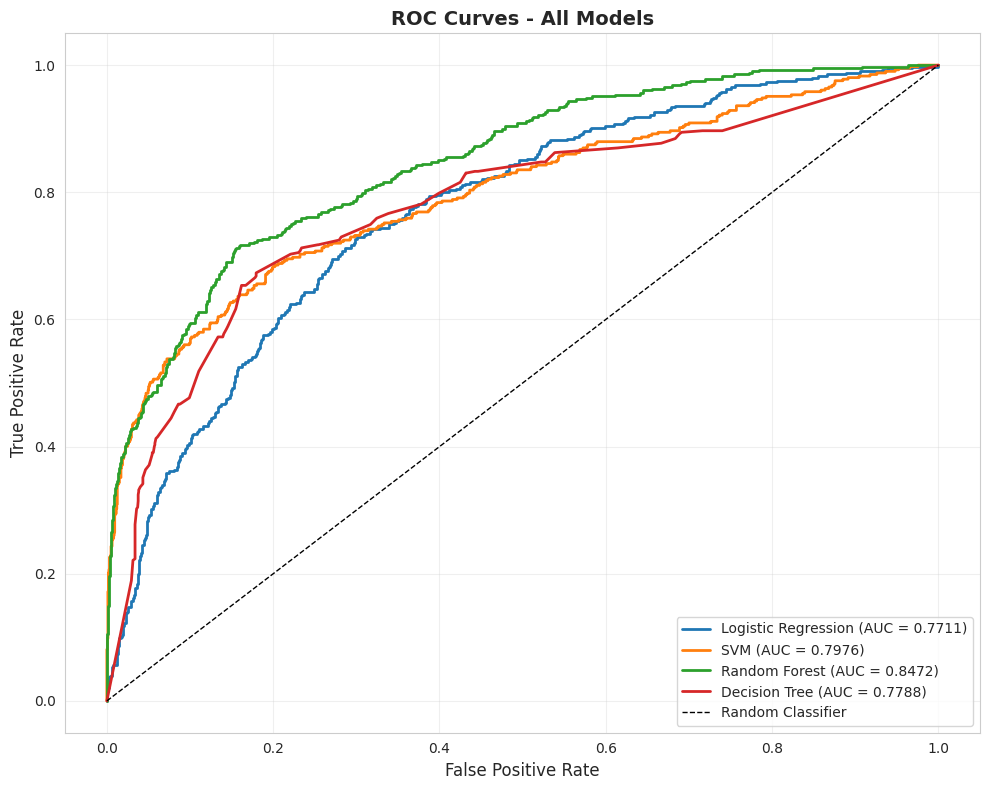

In [19]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

models_proba = [
    ('Logistic Regression', lr_test_proba, lr_auc),
    ('SVM', svm_test_proba, svm_auc),
    ('Random Forest', rf_test_proba, rf_auc),
    ('Decision Tree', dt_test_proba, dt_auc)
]

for model_name, proba, auc in models_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC = {auc:.4f})',
        linewidth=2
    )

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier',
    linewidth=1
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(
    'ROC Curves - All Models',
    fontsize=14,
    fontweight='bold'
)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ROC-AUC Findings

Random Forest achieved the highest ROC-AUC score at 0.8472, providing the strongest overall ability to distinguish between customers who churned and customers who remained.

SVM ranked second with an AUC of 0.7976, followed by Decision Tree at 0.7788 and Logistic Regression at 0.7711.

This result provides further support for Random Forest. Its advantage was not limited to accuracy at a single classification threshold. It also demonstrated the strongest overall discrimination between the two customer outcomes.

## 10. Feature Importance Analysis

Tree-based models provide feature importance scores that help identify which variables contributed most to the models' predictions.

I compared feature importance from Random Forest and Decision Tree to examine whether the two tree-based approaches relied on similar customer characteristics.

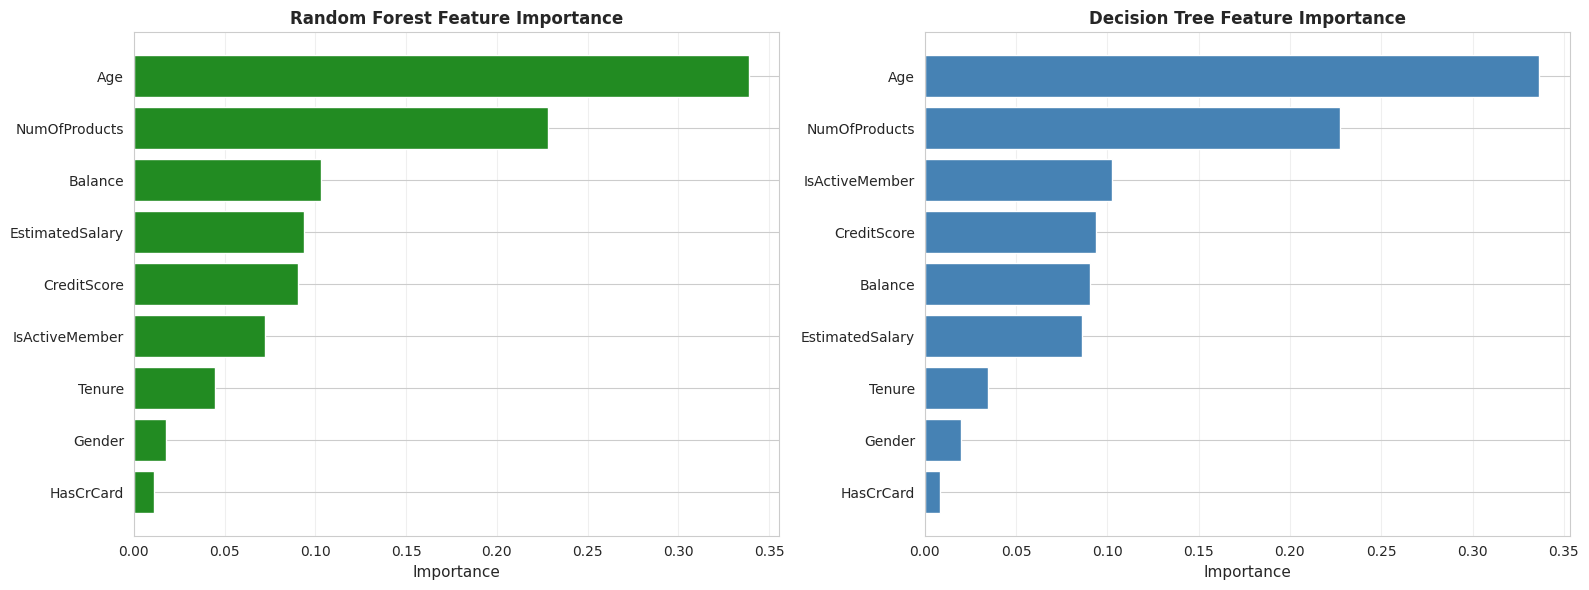

In [20]:
# Visualize feature importance for tree-based models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance
rf_importance_sorted = feature_importance.sort_values(
    'Importance',
    ascending=True
)

axes[0].barh(
    rf_importance_sorted['Feature'],
    rf_importance_sorted['Importance'],
    color='forestgreen'
)

axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title(
    'Random Forest Feature Importance',
    fontsize=12,
    fontweight='bold'
)
axes[0].grid(True, alpha=0.3, axis='x')

# Decision Tree feature importance
dt_importance_sorted = dt_feature_importance.sort_values(
    'Importance',
    ascending=True
)

axes[1].barh(
    dt_importance_sorted['Feature'],
    dt_importance_sorted['Importance'],
    color='steelblue'
)

axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title(
    'Decision Tree Feature Importance',
    fontsize=12,
    fontweight='bold'
)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Feature Importance Findings

Both tree-based models identified `Age` and `NumOfProducts` as the two most influential features in predicting customer churn.

Random Forest assigned approximately 33.87% of total feature importance to `Age` and 22.83% to `NumOfProducts`. Together, these two variables accounted for approximately 57% of the model's total feature importance.

The remaining Random Forest importance was distributed across several customer characteristics, including `Balance`, `EstimatedSalary`, `CreditScore`, and `IsActiveMember`.

Decision Tree showed a similar pattern, also ranking `Age` and `NumOfProducts` first and second. It placed greater relative importance on `IsActiveMember` than Random Forest.

### Connection to Exploratory Analysis

One of the more interesting findings is the difference between correlation and predictive importance.

During exploratory analysis, `NumOfProducts` showed only a weak linear correlation with churn. Despite this, both tree-based models ranked it as the second-most-important predictive feature.

This suggests that the relationship between product usage and churn may be nonlinear or may depend on interactions with other customer characteristics. It also demonstrates why correlation analysis alone is not sufficient for selecting predictive features.

Feature importance indicates how strongly a model relied on each variable when making predictions. It does not establish that these variables caused customers to churn.

## 11. Generalization & Overfitting Analysis

A strong predictive model should perform well not only on the data used for training but also on unseen customers.

To evaluate generalization, I compared training accuracy with testing accuracy for each model. A large decline from training to testing performance can indicate that a model has learned patterns specific to the training data rather than relationships that generalize effectively.

In [21]:
# Analyze overfitting/underfitting
print('Overfitting Analysis (Training vs Testing Accuracy):')
print('\nModel Performance Gap:')

for model_name, train_acc, test_acc in zip(
    comparison_df['Model'],
    comparison_df['Training Accuracy'],
    comparison_df['Testing Accuracy']
):
    gap = train_acc - test_acc

    status = (
        'Overfitting'
        if gap > 0.05
        else 'Good Generalization'
    )

    print(f'{model_name}:')
    print(f' Training Accuracy: {train_acc:.4f}')
    print(f' Testing Accuracy: {test_acc:.4f}')
    print(f' Gap: {gap:.4f} - {status}\n')

Overfitting Analysis (Training vs Testing Accuracy):

Model Performance Gap:
Logistic Regression:
 Training Accuracy: 0.8073
 Testing Accuracy: 0.8050
 Gap: 0.0022 - Good Generalization

SVM:
 Training Accuracy: 0.8596
 Testing Accuracy: 0.8580
 Gap: 0.0016 - Good Generalization

Random Forest:
 Training Accuracy: 0.8938
 Testing Accuracy: 0.8595
 Gap: 0.0343 - Good Generalization

Decision Tree:
 Training Accuracy: 0.8941
 Testing Accuracy: 0.8330
 Gap: 0.0611 - Overfitting



### Generalization Findings

Logistic Regression and SVM showed the smallest differences between training and testing accuracy, with gaps of only 0.22 and 0.16 percentage points, respectively. This indicates highly consistent performance between the training and unseen test data.

Random Forest achieved substantially higher training accuracy at 89.38% and testing accuracy of 85.95%. Its 3.43 percentage-point gap indicates some decline on unseen data, but it remained below the 5-percentage-point threshold used in this analysis to flag potential overfitting.

Decision Tree showed the largest performance gap. Training accuracy reached 89.41%, while testing accuracy declined to 83.30%, resulting in a 6.11 percentage-point gap. Based on the evaluation threshold used in this project, Decision Tree showed evidence of overfitting.

The comparison between Random Forest and Decision Tree is particularly important. Both models achieved nearly identical training accuracy, but Random Forest performed considerably better on the test set. This demonstrates the benefit of the ensemble approach in improving generalization compared with relying on a single decision tree.

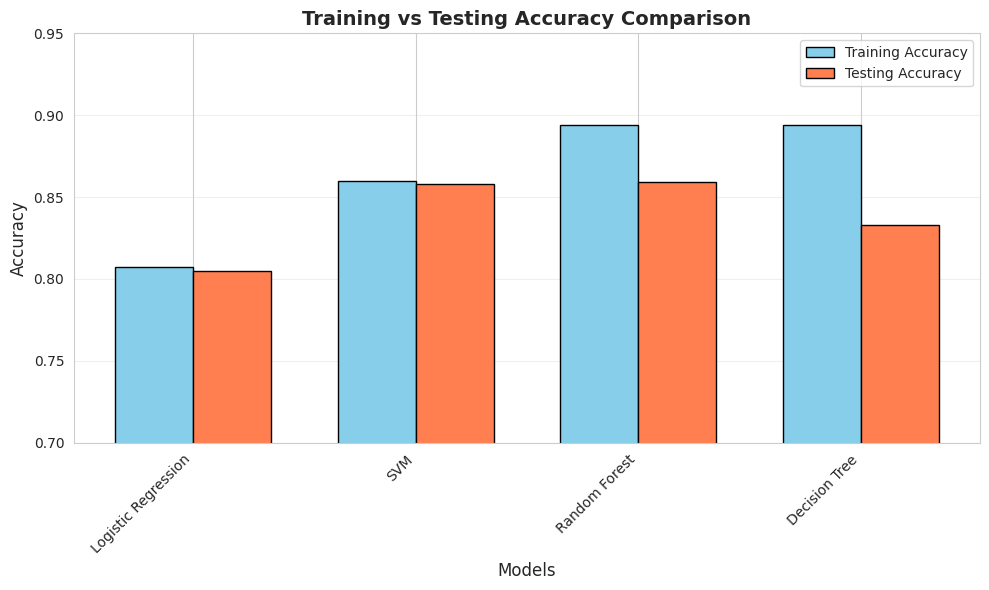

In [22]:
# Visualize training vs testing accuracy
plt.figure(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.35

plt.bar(
    x - width/2,
    comparison_df['Training Accuracy'],
    width,
    label='Training Accuracy',
    color='skyblue',
    edgecolor='black'
)

plt.bar(
    x + width/2,
    comparison_df['Testing Accuracy'],
    width,
    label='Testing Accuracy',
    color='coral',
    edgecolor='black'
)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(
    'Training vs Testing Accuracy Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(
    x,
    comparison_df['Model'],
    rotation=45,
    ha='right'
)

plt.legend()
plt.ylim([0.7, 0.95])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Cross-Validation Performance

Five-fold cross-validation was used as an additional test of model stability.

Rather than evaluating performance using only one train-test split, cross-validation repeatedly evaluates each model across different subsets of the training data. This provides another indication of whether model performance is consistent across different samples.

Cross-Validation vs Test Accuracy Comparison:

Generalization Assessment:
Logistic Regression:
  CV Mean: 0.8074
  Test Accuracy: 0.8050
  Difference: 0.0024 - Excellent Generalization

SVM:
  CV Mean: 0.8506
  Test Accuracy: 0.8580
  Difference: 0.0074 - Excellent Generalization

Random Forest:
  CV Mean: 0.8571
  Test Accuracy: 0.8595
  Difference: 0.0024 - Excellent Generalization

Decision Tree:
  CV Mean: 0.8285
  Test Accuracy: 0.8330
  Difference: 0.0045 - Excellent Generalization



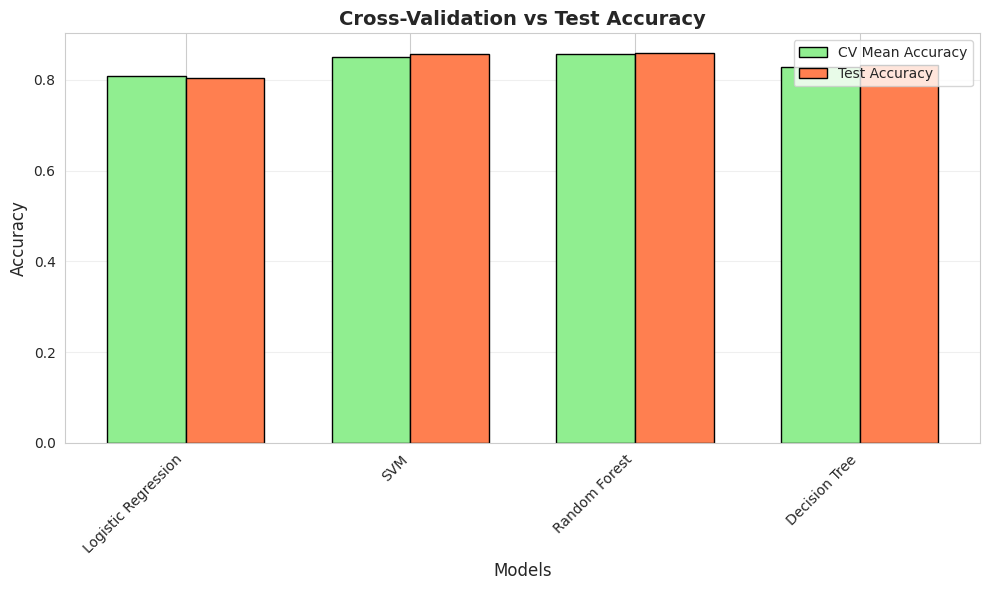

In [23]:
# Compare cross-validation scores with test accuracy
print('Cross-Validation vs Test Accuracy Comparison:')
print('\nGeneralization Assessment:')
for model_name, cv_mean, test_acc in zip(
    comparison_df['Model'],
    comparison_df['CV Mean'],
    comparison_df['Testing Accuracy']
):
    diff = abs(cv_mean - test_acc)
    status = 'Excellent' if diff < 0.01 else 'Good' if diff < 0.02 else 'Fair'
    print(f'{model_name}:')
    print(f'  CV Mean: {cv_mean:.4f}')
    print(f'  Test Accuracy: {test_acc:.4f}')
    print(f'  Difference: {diff:.4f} - {status} Generalization\n')

# Visualize CV scores vs test accuracy
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df['CV Mean'], width,
        label='CV Mean Accuracy', color='lightgreen', edgecolor='black')
plt.bar(x + width/2, comparison_df['Testing Accuracy'], width,
        label='Test Accuracy', color='coral', edgecolor='black')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation vs Test Accuracy', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Cross-Validation Findings

Cross-validation results were consistent with the performance observed on the held-out test set.

Random Forest achieved the highest mean cross-validation accuracy at 85.71%, compared with a testing accuracy of 85.95%. The small difference between these results indicates that its performance remained stable across different subsets of the data.

SVM also demonstrated consistent performance, with cross-validation accuracy of 85.06% and testing accuracy of 85.80%.

Logistic Regression produced cross-validation accuracy of 80.74% compared with testing accuracy of 80.50%, while Decision Tree achieved 82.85% cross-validation accuracy compared with 83.30% testing accuracy.

The close alignment between cross-validation and testing performance provides additional evidence that the model evaluation results are not dependent on a single train-test split.

Combined with its leading testing accuracy, recall, F1-score, and ROC-AUC, Random Forest continued to provide the strongest overall performance.

## 12. Final Model Selection

The final model was selected by considering multiple dimensions of performance rather than relying on a single metric.

The evaluation considered:

- Testing accuracy
- Precision and recall
- F1-score
- ROC-AUC
- Cross-validation performance
- Generalization to unseen data

For this customer churn problem, particular attention was given to recall and F1-score because identifying customers who actually churn is an important part of the business objective.

### Custom Model Selection Framework

To support the final model-selection decision, I created a custom weighted scoring framework that combines several evaluation criteria into a single selection score.

The weighting used in this project is:

| Evaluation Criterion | Weight |
|---|---:|
| Testing Accuracy | 30% |
| F1-Score | 25% |
| ROC-AUC | 25% |
| Cross-Validation Accuracy | 15% |
| Generalization | 5% |

Testing accuracy receives the highest individual weight, while F1-score and ROC-AUC receive substantial weight because the churn target is imbalanced and correctly identifying the minority class is important.

Cross-validation contributes to the score as a measure of model stability. Generalization is represented by penalizing the difference between training and testing accuracy.

The resulting `Selection Score` is a project-specific decision framework rather than a standard machine learning evaluation metric. It is used to support comparison across the models and should be interpreted alongside the individual performance metrics.

In [25]:
# Final model selection using a custom weighted scoring framework

print('Final Model Ranking and Selection')

# Create ranking dataframe
ranking_df = comparison_df.copy()

# Measure the difference between training and testing performance
ranking_df['Overfitting Gap'] = (
    ranking_df['Training Accuracy']
    - ranking_df['Testing Accuracy']
)

# Custom weighted model-selection score
ranking_df['Selection Score'] = (
    ranking_df['Testing Accuracy'] * 0.30 +
    ranking_df['F1-Score'] * 0.25 +
    ranking_df['AUC-ROC'] * 0.25 +
    ranking_df['CV Mean'] * 0.15 +
    (1 - ranking_df['Overfitting Gap']) * 0.05
)

# Rank models from highest to lowest score
ranking_df = ranking_df.sort_values(
    'Selection Score',
    ascending=False
).reset_index(drop=True)

# Display key ranking metrics
display(
    ranking_df[
        [
            'Model',
            'Testing Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            'AUC-ROC',
            'CV Mean',
            'Overfitting Gap',
            'Selection Score'
        ]
    ].round(4)
)

best_model = ranking_df.iloc[0]['Model']

print(f'\nRecommended Model: {best_model}')

Final Model Ranking and Selection


,Model,Testing Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV Mean,Overfitting Gap,Selection Score
0,Random Forest,0.8595,0.8000,0.4128,0.5446,0.8472,0.8571,0.0342,0.7826
1,SVM,0.8580,0.8361,0.3759,0.5186,0.7976,0.8506,0.0016,0.7640
2,Decision Tree,0.8330,0.6420,0.4054,0.4970,0.7788,0.8285,0.0611,0.7401
3,Logistic Regression,0.8050,0.5825,0.1474,0.2353,0.7711,0.8074,0.0022,0.6641



Recommended Model: Random Forest


### Final Model: Random Forest

Random Forest was selected as the final model because it provided the strongest overall balance across the evaluation criteria.

Among the four models, Random Forest achieved:

- Highest testing accuracy: 85.95%
- Highest recall: 41.28%
- Highest F1-score: 0.5446
- Highest ROC-AUC: 0.8472
- Highest cross-validation accuracy: 85.71%
- Precision of 80.00%

SVM achieved slightly higher precision at 83.61%, but Random Forest identified a larger proportion of customers who actually churned and achieved stronger overall discrimination.

Random Forest also generalized better than the standalone Decision Tree. Although both models achieved approximately 89.4% training accuracy, Random Forest maintained 85.95% accuracy on unseen test data compared with 83.30% for Decision Tree.

Taken together, these results make Random Forest the strongest candidate for the customer churn prediction objective.

## 13. Business Recommendations & Next Steps

### Translating Predictions into Business Decisions

The purpose of the model is not simply to predict whether a customer may churn. Its value comes from helping the business identify customers who may require attention before they leave.

The Random Forest model could serve as the foundation for a churn risk-scoring process in which customers receive predicted churn probabilities based on their demographic, financial, product, and account activity characteristics.

A potential decision workflow could be:

**Customer Data → Churn Prediction → Risk Score → Customer Segment → Retention Action → Outcome Measurement**

Rather than applying the same retention strategy to every customer, the bank could use model predictions to prioritize customers for further analysis and targeted intervention.

### Potential Business Actions

Customers identified as having elevated churn risk could be considered for:

- Proactive customer outreach
- Review of current product relationships
- Personalized retention offers
- Customer service follow-up
- Account engagement analysis
- Targeted retention campaigns

The feature importance analysis can also help guide further investigation. `Age` and `NumOfProducts` were the two most influential features in the Random Forest model, followed by `Balance`, `EstimatedSalary`, and `CreditScore`.

These results should guide additional analysis rather than be interpreted as evidence that these characteristics cause churn.

### Model Limitations

The analysis also identified several limitations that should be considered before using the model in a production environment.

- The churn target is imbalanced, with approximately 20% of customers belonging to the churn class.
- Random Forest identified 41.28% of actual churners, meaning a substantial number of churners were still missed.
- The analysis uses a default classification threshold rather than a threshold optimized around business costs.
- Feature importance describes predictive contribution but does not establish causation.
- Model performance was evaluated using one customer dataset rather than data collected across multiple time periods.
- The analysis evaluates predictive performance but does not measure whether a retention intervention would successfully prevent churn.

### Future Improvements

Future iterations of the project could extend the analysis by:

- Tuning Random Forest hyperparameters
- Evaluating class-weighted models to address class imbalance
- Comparing additional ensemble and boosting algorithms
- Evaluating Precision-Recall curves
- Optimizing the classification threshold based on the cost of false positives and false negatives
- Using SHAP values to improve model explainability
- Converting churn probabilities into actionable customer risk segments
- Incorporating customer lifetime value into retention prioritization
- Measuring the financial impact of retention campaigns
- Monitoring model performance and data drift over time

### Final Takeaway

This project demonstrates why predictive model selection requires more than choosing the algorithm with the highest accuracy.

Logistic Regression provided a stable baseline but struggled to identify customers who churned. SVM substantially improved precision and recall. Decision Tree captured more churners but showed greater overfitting and produced more false-positive predictions.

Random Forest provided the strongest overall balance. It achieved 85.95% testing accuracy, 41.28% recall, a 0.5446 F1-score, and a 0.8472 ROC-AUC while maintaining stable cross-validation performance.

The final result is a predictive modeling framework that can help move customer retention from broad outreach toward more targeted, data-informed decision-making.

---

## Project Summary

**Business Problem:** Customer churn prediction

**Target Variable:** `Exited`

**Dataset Size:** 10,000 customers

**Models Evaluated:**
- Logistic Regression
- Support Vector Machine
- Random Forest
- Decision Tree

**Selected Model:** Random Forest

**Final Model Performance:**
- Testing Accuracy: 85.95%
- Precision: 80.00%
- Recall: 41.28%
- F1-Score: 0.5446
- ROC-AUC: 0.8472
- 5-Fold CV Accuracy: 85.71%

**Primary Tools:** Python, pandas, NumPy, scikit-learn, Matplotlib, Seaborn